# Загрузка Pandas и очистка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from datetime import datetime, timedelta
import re 
%matplotlib inline

In [2]:
RANDOM_SEED = 42

In [3]:
!pip freeze > requirements.txt

In [4]:
df = pd.read_csv('main_task.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Restaurant_id      40000 non-null  object 
 1   City               40000 non-null  object 
 2   Cuisine Style      30717 non-null  object 
 3   Ranking            40000 non-null  float64
 4   Rating             40000 non-null  float64
 5   Price Range        26114 non-null  object 
 6   Number of Reviews  37457 non-null  float64
 7   Reviews            40000 non-null  object 
 8   URL_TA             40000 non-null  object 
 9   ID_TA              40000 non-null  object 
dtypes: float64(3), object(7)
memory usage: 3.1+ MB


,Restaurant_id,City,Cuisine Style,Ranking,Rating,Price Range,Number of Reviews,Reviews,URL_TA,ID_TA
0,id_5569,Paris,"['European', 'French', 'International']",5570.0,3.5,$$ - $$$,194.0,"[['Good food at your doorstep', 'A good hotel ...",/Restaurant_Review-g187147-d1912643-Reviews-R_...,d1912643
1,id_1535,Stockholm,NaN,1537.0,4.0,NaN,10.0,"[['Unique cuisine', 'Delicious Nepalese food']...",/Restaurant_Review-g189852-d7992032-Reviews-Bu...,d7992032
2,id_352,London,"['Japanese', 'Sushi', 'Asian', 'Grill', 'Veget...",353.0,4.5,$$$$,688.0,"[['Catch up with friends', 'Not exceptional'],...",/Restaurant_Review-g186338-d8632781-Reviews-RO...,d8632781
3,id_3456,Berlin,NaN,3458.0,5.0,NaN,3.0,"[[], []]",/Restaurant_Review-g187323-d1358776-Reviews-Es...,d1358776
4,id_615,Munich,"['German', 'Central European', 'Vegetarian Fri...",621.0,4.0,$$ - $$$,84.0,"[['Best place to try a Bavarian food', 'Nice b...",/Restaurant_Review-g187309-d6864963-Reviews-Au...,d6864963


# Генерация новых признаков

Создание признака "Count of cuisines" - количество кухонь в ресторане. Для начала определим количество уникальных кухонь для общей информации и самую популярную кухню, значением которой мы заполним пропуски в столбце "Cuisine Style".

In [5]:
df = df.dropna(subset = ['Cuisine Style'])

df['Cuisine Style'] = df['Cuisine Style'].apply(lambda x: str(x[1:-1]).split(', '))

list_of_cuisines = []
for cuisines in df['Cuisine Style']:
    for cuisine in cuisines:
            list_of_cuisines.append(cuisine)
list_of_cuisines[:5]

["'European'", "'French'", "'International'", "'Japanese'", "'Sushi'"]

In [6]:
data_of_cuisines = pd.Series(list_of_cuisines)
len(data_of_cuisines.unique())

125

После извлечения названий таким способом мы безошибочно получаем количество уникальных кухонь, но у их названий остаются 
ненужные кавычки. Поэтому извлечем их с помощью регулярных выражений, но сначала просмотрим весь список, для того чтобы 
составить правильный шаблон.

In [7]:
data_of_cuisines.unique()

array(["'European'", "'French'", "'International'", "'Japanese'",
       "'Sushi'", "'Asian'", "'Grill'", "'Vegetarian Friendly'",
       "'Vegan Options'", "'Gluten Free Options'", "'German'",
       "'Central European'", "'Italian'", "'Pizza'", "'Fast Food'",
       "'Mediterranean'", "'Spanish'", "'Healthy'", "'Cafe'", "'Thai'",
       "'Vietnamese'", "'Bar'", "'Pub'", "'Chinese'", "'British'",
       "'Polish'", "'Fusion'", "'Dutch'", "'Mexican'", "'Venezuelan'",
       "'South American'", "'Soups'", "'Belgian'", "'Steakhouse'",
       "'Latin'", "'Barbecue'", "'Argentinean'", "'Irish'", "'Seafood'",
       "'Swiss'", "'Portuguese'", "'Contemporary'", "'Wine Bar'",
       "'Greek'", "'Central American'", "'Indian'", "'Middle Eastern'",
       "'Turkish'", "'Hungarian'", "'Pakistani'", "'Peruvian'",
       "'Delicatessen'", "'Eastern European'", "'Swedish'",
       "'Scandinavian'", "'Tibetan'", "'Nepali'", "'Korean'",
       "'Southwestern'", "'Czech'", "'American'", "'Slovenian'",

In [8]:
df = pd.read_csv('main_task.csv')

df = df.dropna(subset = ['Cuisine Style'])

list_of_cuisines = []
pattern = re.compile('\w+\s*\&*\s*\w*\s*\&*\s*\w*')
for cuisines in df['Cuisine Style']:
    for cuisine in pattern.findall(cuisines):
        list_of_cuisines.append(cuisine)
list_of_cuisines[:5]

['European', 'French', 'International', 'Japanese', 'Sushi']

In [9]:
data_of_cuisines = pd.Series(list_of_cuisines)
len(data_of_cuisines.unique())

125

Количество сходится, значит всё верно.

In [10]:
data_of_cuisines.value_counts()

Vegetarian Friendly    11189
European               10060
Mediterranean           6277
Italian                 5964
Vegan Options           4486
                       ...  
Salvadoran                 1
Latvian                    1
Burmese                    1
Yunnan                     1
Xinjiang                   1
Length: 125, dtype: int64

In [11]:
df = pd.read_csv('main_task.csv')

#заполняем пустые ячейки в столбце Cuisine Style значением моды и переводим все значения в тип данных лист
df['Cuisine Style'] = df['Cuisine Style'].apply(lambda x: ['Vegetarian Friendly'] if pd.isnull(x) else pattern.findall(x))

#создаем столбец Count of cuisines и заполняем его нулями
df['Count of cuisines'] = 0

#проходим по каждому ресторану и заполняем столбец Count of Cuisines количеством кухонь в нем
for i in df.index:
    df['Count of cuisines'].iloc[i] = len(df['Cuisine Style'].iloc[i])

C:\Anaconda3\lib\site-packages\pandas\core\indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_with_indexer(indexer, value)


In [12]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Restaurant_id      40000 non-null  object 
 1   City               40000 non-null  object 
 2   Cuisine Style      40000 non-null  object 
 3   Ranking            40000 non-null  float64
 4   Rating             40000 non-null  float64
 5   Price Range        26114 non-null  object 
 6   Number of Reviews  37457 non-null  float64
 7   Reviews            40000 non-null  object 
 8   URL_TA             40000 non-null  object 
 9   ID_TA              40000 non-null  object 
 10  Count of cuisines  40000 non-null  int64  
dtypes: float64(3), int64(1), object(7)
memory usage: 3.4+ MB


,Restaurant_id,City,Cuisine Style,Ranking,Rating,Price Range,Number of Reviews,Reviews,URL_TA,ID_TA,Count of cuisines
0,id_5569,Paris,"[European, French, International]",5570.0,3.5,$$ - $$$,194.0,"[['Good food at your doorstep', 'A good hotel ...",/Restaurant_Review-g187147-d1912643-Reviews-R_...,d1912643,3
1,id_1535,Stockholm,[Vegetarian Friendly],1537.0,4.0,NaN,10.0,"[['Unique cuisine', 'Delicious Nepalese food']...",/Restaurant_Review-g189852-d7992032-Reviews-Bu...,d7992032,1
2,id_352,London,"[Japanese, Sushi, Asian, Grill, Vegetarian Fri...",353.0,4.5,$$$$,688.0,"[['Catch up with friends', 'Not exceptional'],...",/Restaurant_Review-g186338-d8632781-Reviews-RO...,d8632781,7
3,id_3456,Berlin,[Vegetarian Friendly],3458.0,5.0,NaN,3.0,"[[], []]",/Restaurant_Review-g187323-d1358776-Reviews-Es...,d1358776,1
4,id_615,Munich,"[German, Central European, Vegetarian Friendly]",621.0,4.0,$$ - $$$,84.0,"[['Best place to try a Bavarian food', 'Nice b...",/Restaurant_Review-g187309-d6864963-Reviews-Au...,d6864963,3


Создадим столбец "Number of Reviews isNaN", куда вынесем информацию о наличии пропусков в столбце "Number of Reviews" как отдельный признак.

In [13]:
df['Number of Reviews isNAN'] = pd.isna(df['Number of Reviews']).astype('uint8')

Создание признака "Time Difference" - количество дней, разделяющих даты публикации двух отзывов.

In [15]:
#извлекаем даты отзывов из столбца Reviews в отдельный список
list_of_dates = []
pattern = re.compile('\d+\/\d+\/\d+')
for review in df.Reviews:
    list_of_dates.append(pattern.findall(review))
list_of_dates[:3]    

[['12/31/2017', '11/20/2017'],
 ['07/06/2017', '06/19/2016'],
 ['01/08/2018', '01/06/2018']]

In [16]:
#создаем два столбца, в которые будем записывать даты первого и второго отзыва соответственно
df['First Review'] = ''
df['Second Review'] = ''

#Осуществляем запись. Так как в данных иногда присутствует только одна дата, код имеет такую структуру
for i, dates in enumerate(list_of_dates):
    if len(dates) == 2:
        df['First Review'].iloc[i] = dates[0]
        df['Second Review'].iloc[i] = dates[1]
    elif len(dates) == 1:
        df['First Review'].iloc[i] = dates[0]
    else:
        continue

#Переводим строковые данные в формат datetime и вычисляем разницу во времени между датами. Одновременно переводим всё
#в формат int и берем абсолютное значение от числа 
df['First Review'] = pd.to_datetime(df['First Review'])
df['Second Review'] = pd.to_datetime(df['Second Review'])
df['Time Difference'] = abs((df['First Review'] - df['Second Review'])/np.timedelta64(1, "D"))

C:\Anaconda3\lib\site-packages\pandas\core\indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_with_indexer(indexer, value)


In [17]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Restaurant_id            40000 non-null  object        
 1   City                     40000 non-null  object        
 2   Cuisine Style            40000 non-null  object        
 3   Ranking                  40000 non-null  float64       
 4   Rating                   40000 non-null  float64       
 5   Price Range              26114 non-null  object        
 6   Number of Reviews        37457 non-null  float64       
 7   Reviews                  40000 non-null  object        
 8   URL_TA                   40000 non-null  object        
 9   ID_TA                    40000 non-null  object        
 10  Count of cuisines        40000 non-null  int64         
 11  Number of Reviews isNAN  40000 non-null  uint8         
 12  First Review             33527 n

,Restaurant_id,City,Cuisine Style,Ranking,Rating,Price Range,Number of Reviews,Reviews,URL_TA,ID_TA,Count of cuisines,Number of Reviews isNAN,First Review,Second Review,Time Difference
0,id_5569,Paris,"[European, French, International]",5570.0,3.5,$$ - $$$,194.0,"[['Good food at your doorstep', 'A good hotel ...",/Restaurant_Review-g187147-d1912643-Reviews-R_...,d1912643,3,0,2017-12-31,2017-11-20,41.0
1,id_1535,Stockholm,[Vegetarian Friendly],1537.0,4.0,NaN,10.0,"[['Unique cuisine', 'Delicious Nepalese food']...",/Restaurant_Review-g189852-d7992032-Reviews-Bu...,d7992032,1,0,2017-07-06,2016-06-19,382.0
2,id_352,London,"[Japanese, Sushi, Asian, Grill, Vegetarian Fri...",353.0,4.5,$$$$,688.0,"[['Catch up with friends', 'Not exceptional'],...",/Restaurant_Review-g186338-d8632781-Reviews-RO...,d8632781,7,0,2018-01-08,2018-01-06,2.0
3,id_3456,Berlin,[Vegetarian Friendly],3458.0,5.0,NaN,3.0,"[[], []]",/Restaurant_Review-g187323-d1358776-Reviews-Es...,d1358776,1,0,NaT,NaT,NaN
4,id_615,Munich,"[German, Central European, Vegetarian Friendly]",621.0,4.0,$$ - $$$,84.0,"[['Best place to try a Bavarian food', 'Nice b...",/Restaurant_Review-g187309-d6864963-Reviews-Au...,d6864963,3,0,2017-11-18,2017-02-19,272.0


In [18]:
df['Time Difference'].median()

67.0

Заполним пропуски в столбце "Time Difference" значением медианы.

In [19]:
df['Time Difference'] = df['Time Difference'].fillna(df['Time Difference'].median())

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Restaurant_id            40000 non-null  object        
 1   City                     40000 non-null  object        
 2   Cuisine Style            40000 non-null  object        
 3   Ranking                  40000 non-null  float64       
 4   Rating                   40000 non-null  float64       
 5   Price Range              26114 non-null  object        
 6   Number of Reviews        37457 non-null  float64       
 7   Reviews                  40000 non-null  object        
 8   URL_TA                   40000 non-null  object        
 9   ID_TA                    40000 non-null  object        
 10  Count of cuisines        40000 non-null  int64         
 11  Number of Reviews isNAN  40000 non-null  uint8         
 12  First Review             33527 n

Создание признака "Num Price Range" - уровень ценового диапазона, выраженный в числовом эквиваленте.

In [21]:
df['Price Range'].value_counts()

$$ - $$$    18412
$            6279
$$$$         1423
Name: Price Range, dtype: int64

In [22]:
df['Price Range'] = df['Price Range'].fillna('$$ - $$$')#заполняем пропуски значением моды

price_range_dict = {'$':1, '$$ - $$$':2, '$$$$':3}#создаем словарь соответствий строковых значений числам

df['Num Price Range'] = df['Price Range'].replace(to_replace = price_range_dict)#производим замену

Создадим признак "Count of restaurants", показывающий количество ресторанов в городе, в котором находится ресторан.

In [23]:
#создаем столбец Count of Restaurants
df['Count of Restaurants'] = 0

#заполняем его
for i in df.index:
    df['Count of Restaurants'].iloc[i] = len(df[df['City'] == df['City'].iloc[i]])

C:\Anaconda3\lib\site-packages\pandas\core\indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_with_indexer(indexer, value)


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Restaurant_id            40000 non-null  object        
 1   City                     40000 non-null  object        
 2   Cuisine Style            40000 non-null  object        
 3   Ranking                  40000 non-null  float64       
 4   Rating                   40000 non-null  float64       
 5   Price Range              40000 non-null  object        
 6   Number of Reviews        37457 non-null  float64       
 7   Reviews                  40000 non-null  object        
 8   URL_TA                   40000 non-null  object        
 9   ID_TA                    40000 non-null  object        
 10  Count of cuisines        40000 non-null  int64         
 11  Number of Reviews isNAN  40000 non-null  uint8         
 12  First Review             33527 n

В результате создано 5 новых числовых признаков

Заполним пропуски в столбце "Number of Reviews" нулем.

In [25]:
df['Number of Reviews'] = df['Number of Reviews'].fillna(0)

In [26]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Restaurant_id            40000 non-null  object        
 1   City                     40000 non-null  object        
 2   Cuisine Style            40000 non-null  object        
 3   Ranking                  40000 non-null  float64       
 4   Rating                   40000 non-null  float64       
 5   Price Range              40000 non-null  object        
 6   Number of Reviews        40000 non-null  float64       
 7   Reviews                  40000 non-null  object        
 8   URL_TA                   40000 non-null  object        
 9   ID_TA                    40000 non-null  object        
 10  Count of cuisines        40000 non-null  int64         
 11  Number of Reviews isNAN  40000 non-null  uint8         
 12  First Review             33527 n

,Restaurant_id,City,Cuisine Style,Ranking,Rating,Price Range,Number of Reviews,Reviews,URL_TA,ID_TA,Count of cuisines,Number of Reviews isNAN,First Review,Second Review,Time Difference,Num Price Range,Count of Restaurants
0,id_5569,Paris,"[European, French, International]",5570.0,3.5,$$ - $$$,194.0,"[['Good food at your doorstep', 'A good hotel ...",/Restaurant_Review-g187147-d1912643-Reviews-R_...,d1912643,3,0,2017-12-31,2017-11-20,41.0,2,4897
1,id_1535,Stockholm,[Vegetarian Friendly],1537.0,4.0,$$ - $$$,10.0,"[['Unique cuisine', 'Delicious Nepalese food']...",/Restaurant_Review-g189852-d7992032-Reviews-Bu...,d7992032,1,0,2017-07-06,2016-06-19,382.0,2,820
2,id_352,London,"[Japanese, Sushi, Asian, Grill, Vegetarian Fri...",353.0,4.5,$$$$,688.0,"[['Catch up with friends', 'Not exceptional'],...",/Restaurant_Review-g186338-d8632781-Reviews-RO...,d8632781,7,0,2018-01-08,2018-01-06,2.0,3,5757
3,id_3456,Berlin,[Vegetarian Friendly],3458.0,5.0,$$ - $$$,3.0,"[[], []]",/Restaurant_Review-g187323-d1358776-Reviews-Es...,d1358776,1,0,NaT,NaT,67.0,2,2155
4,id_615,Munich,"[German, Central European, Vegetarian Friendly]",621.0,4.0,$$ - $$$,84.0,"[['Best place to try a Bavarian food', 'Nice b...",/Restaurant_Review-g187309-d6864963-Reviews-Au...,d6864963,3,0,2017-11-18,2017-02-19,272.0,2,893


## Dummy-переменные.

Для начала возьмем признак "City".

In [27]:
df = pd.get_dummies(df, columns = ['City'])

In [28]:
len(df.columns)

47

In [29]:
df.head()

,Restaurant_id,Cuisine Style,Ranking,Rating,Price Range,Number of Reviews,Reviews,URL_TA,ID_TA,Count of cuisines,...,City_Munich,City_Oporto,City_Oslo,City_Paris,City_Prague,City_Rome,City_Stockholm,City_Vienna,City_Warsaw,City_Zurich
0,id_5569,"[European, French, International]",5570.0,3.5,$$ - $$$,194.0,"[['Good food at your doorstep', 'A good hotel ...",/Restaurant_Review-g187147-d1912643-Reviews-R_...,d1912643,3,...,0,0,0,1,0,0,0,0,0,0
1,id_1535,[Vegetarian Friendly],1537.0,4.0,$$ - $$$,10.0,"[['Unique cuisine', 'Delicious Nepalese food']...",/Restaurant_Review-g189852-d7992032-Reviews-Bu...,d7992032,1,...,0,0,0,0,0,0,1,0,0,0
2,id_352,"[Japanese, Sushi, Asian, Grill, Vegetarian Fri...",353.0,4.5,$$$$,688.0,"[['Catch up with friends', 'Not exceptional'],...",/Restaurant_Review-g186338-d8632781-Reviews-RO...,d8632781,7,...,0,0,0,0,0,0,0,0,0,0
3,id_3456,[Vegetarian Friendly],3458.0,5.0,$$ - $$$,3.0,"[[], []]",/Restaurant_Review-g187323-d1358776-Reviews-Es...,d1358776,1,...,0,0,0,0,0,0,0,0,0,0
4,id_615,"[German, Central European, Vegetarian Friendly]",621.0,4.0,$$ - $$$,84.0,"[['Best place to try a Bavarian food', 'Nice b...",/Restaurant_Review-g187309-d6864963-Reviews-Au...,d6864963,3,...,1,0,0,0,0,0,0,0,0,0


Теперь вручную создадим dummy-переменные по признаку "Cuisine Style".

 Создадим датасет размерностью 40000 rows х 125 columns и заполним его нулями.

In [30]:
data = pd.DataFrame([[0 for i in range(125)] for j in range(40000)], columns = data_of_cuisines.value_counts().index[:125],\
                    index = [x for x in range(40000)])

Соединим этот датасет с исходным датафреймом.

In [31]:
df = pd.concat([df, data], axis = 1)

In [32]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Columns: 172 entries, Restaurant_id to Xinjiang
dtypes: datetime64[ns](2), float64(4), int64(128), object(6), uint8(32)
memory usage: 43.9+ MB


,Restaurant_id,Cuisine Style,Ranking,Rating,Price Range,Number of Reviews,Reviews,URL_TA,ID_TA,Count of cuisines,...,Ecuadorean,Fujian,Welsh,Polynesian,Azerbaijani,Salvadoran,Latvian,Burmese,Yunnan,Xinjiang
0,id_5569,"[European, French, International]",5570.0,3.5,$$ - $$$,194.0,"[['Good food at your doorstep', 'A good hotel ...",/Restaurant_Review-g187147-d1912643-Reviews-R_...,d1912643,3,...,0,0,0,0,0,0,0,0,0,0
1,id_1535,[Vegetarian Friendly],1537.0,4.0,$$ - $$$,10.0,"[['Unique cuisine', 'Delicious Nepalese food']...",/Restaurant_Review-g189852-d7992032-Reviews-Bu...,d7992032,1,...,0,0,0,0,0,0,0,0,0,0
2,id_352,"[Japanese, Sushi, Asian, Grill, Vegetarian Fri...",353.0,4.5,$$$$,688.0,"[['Catch up with friends', 'Not exceptional'],...",/Restaurant_Review-g186338-d8632781-Reviews-RO...,d8632781,7,...,0,0,0,0,0,0,0,0,0,0
3,id_3456,[Vegetarian Friendly],3458.0,5.0,$$ - $$$,3.0,"[[], []]",/Restaurant_Review-g187323-d1358776-Reviews-Es...,d1358776,1,...,0,0,0,0,0,0,0,0,0,0
4,id_615,"[German, Central European, Vegetarian Friendly]",621.0,4.0,$$ - $$$,84.0,"[['Best place to try a Bavarian food', 'Nice b...",/Restaurant_Review-g187309-d6864963-Reviews-Au...,d6864963,3,...,0,0,0,0,0,0,0,0,0,0


Теперь заполним получившийся датафрейм. Время выполнения кода около 35 минут.

In [33]:
#берем каждую колонку с названием кухни и проходим по каждому ресторану, записывая в соответствующей ячейке данной колонки 1 
#или 0 в зависимости от того есть эта кухня в ресторане или нет

for column in df.columns[47:]:
    for i in df.index:
        if column in df['Cuisine Style'].iloc[i]:
            df[column].iloc[i] = 1
        else:
            df[column].iloc[i] = 0

C:\Anaconda3\lib\site-packages\pandas\core\indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_with_indexer(indexer, value)


Удалим все категориальные признаки.

In [39]:
df = df.drop(['Restaurant_id', 'Cuisine Style', 'Price Range', 'Reviews', 'URL_TA', 'ID_TA', 'First Review',\
              'Second Review'], axis = 1)

# Поиск выбросов

Посмотрим на столбец Time Difference.

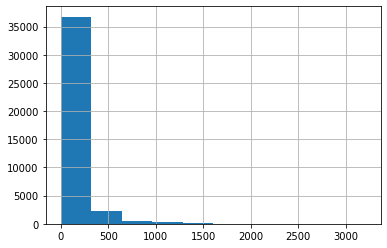

In [40]:
df['Time Difference'].hist(bins = 10)

В данном столбце присутствуют выбросы. Определим их границы, а также рассчитаем другие статистические показатели.

25-й перцентиль: 34.0, 75-й перцентиль: 120.0, IQR: 86.0,  Границы выбросов: [0, 249.0].


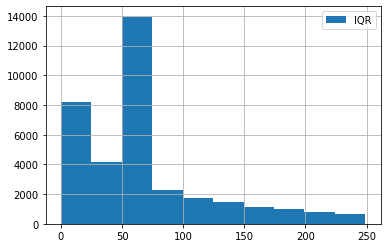

In [41]:
median = df['Time Difference'].median()
IQR = df['Time Difference'].quantile(0.75) - df['Time Difference'].quantile(0.25)
perc25 = df['Time Difference'].quantile(0.25)
perc75 = df['Time Difference'].quantile(0.75)
print('25-й перцентиль: {},'.format(perc25), '75-й перцентиль: {},'.format(perc75)
      , "IQR: {}, ".format(IQR),"Границы выбросов: [{f}, {l}].".format(f=0, l=perc75 + 1.5*IQR))
df['Time Difference'].loc[df['Time Difference'].between(0, perc75 + 1.5*IQR)].hist(bins = 10,\
                                                                                                  range = (0, perc75 + 1.5*IQR), 
                                                                                             label = 'IQR')
plt.legend()

In [44]:
df.corr()

,Ranking,Rating,Number of Reviews,Count of cuisines,Number of Reviews isNAN,Time Difference,Num Price Range,Count of Restaurants,City_Amsterdam,City_Athens,...,Ecuadorean,Fujian,Welsh,Polynesian,Azerbaijani,Salvadoran,Latvian,Burmese,Yunnan,Xinjiang
Ranking,1.000000,-0.368371,-0.222072,-0.320250,0.094078,0.091436,-0.026525,0.709115,-0.094372,-0.095177,...,0.008017,-0.003196,-0.004871,-0.005543,-0.004919,-0.002304,-0.003433,0.005123,-0.002888,0.003640
Rating,-0.368371,1.000000,0.026924,0.120059,0.008386,-0.070791,-0.028588,-0.061376,0.034535,0.044792,...,-0.012987,0.005363,0.005363,-0.007861,0.002718,0.000052,0.007533,0.007533,0.000052,0.000052
Number of Reviews,-0.222072,0.026924,1.000000,0.405641,-0.105853,-0.125435,0.107162,0.027806,0.013348,-0.010741,...,-0.003646,-0.001754,0.003259,0.001588,-0.001718,0.002835,-0.001944,-0.001944,0.001184,-0.001319
Count of cuisines,-0.320250,0.120059,0.405641,1.000000,-0.175335,-0.184012,0.003177,-0.023936,0.063322,-0.002088,...,0.000702,0.003415,0.007306,0.005360,0.018979,0.006542,0.009293,0.003790,0.006542,-0.001712
Number of Reviews isNAN,0.094078,0.008386,-0.105853,-0.175335,1.000000,-0.073759,0.040268,-0.023637,-0.012005,-0.000762,...,0.017888,-0.001842,-0.001842,-0.001842,-0.001842,-0.001303,-0.001303,-0.001303,-0.001303,-0.001303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Salvadoran,-0.002304,0.000052,0.002835,0.006542,-0.001303,0.002194,0.001440,0.001455,-0.000835,-0.000631,...,-0.000050,-0.000035,-0.000035,-0.000035,-0.000035,1.000000,-0.000025,-0.000025,-0.000025,-0.000025
Latvian,-0.003433,0.007533,-0.001944,0.009293,-0.001303,0.000442,-0.010418,-0.004699,-0.000835,-0.000631,...,-0.000050,-0.000035,-0.000035,-0.000035,-0.000035,-0.000025,1.000000,-0.000025,-0.000025,-0.000025
Burmese,0.005123,0.007533,-0.001944,0.003790,-0.001303,-0.002148,-0.010418,0.008568,-0.000835,-0.000631,...,-0.000050,-0.000035,-0.000035,-0.000035,-0.000035,-0.000025,-0.000025,1.000000,-0.000025,-0.000025
Yunnan,-0.002888,0.000052,0.001184,0.006542,-0.001303,-0.000500,0.001440,0.000451,-0.000835,-0.000631,...,-0.000050,-0.000035,-0.000035,-0.000035,-0.000035,-0.000025,-0.000025,-0.000025,1.000000,-0.000025


Различные пробы показали, что улучшение модели происходит только в случае удаления выбросов, но в соревновании на Kaggle это сделать невозможно по условию задачи. Поэтому оставляем выбросы.

In [42]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Columns: 164 entries, Ranking to Xinjiang
dtypes: float64(4), int64(128), uint8(32)
memory usage: 41.5 MB


,Ranking,Rating,Number of Reviews,Count of cuisines,Number of Reviews isNAN,Time Difference,Num Price Range,Count of Restaurants,City_Amsterdam,City_Athens,...,Ecuadorean,Fujian,Welsh,Polynesian,Azerbaijani,Salvadoran,Latvian,Burmese,Yunnan,Xinjiang
0,5570.0,3.5,194.0,3,0,41.0,2,4897,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1537.0,4.0,10.0,1,0,382.0,2,820,0,0,...,0,0,0,0,0,0,0,0,0,0
2,353.0,4.5,688.0,7,0,2.0,3,5757,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3458.0,5.0,3.0,1,0,67.0,2,2155,0,0,...,0,0,0,0,0,0,0,0,0,0
4,621.0,4.0,84.0,3,0,272.0,2,893,0,0,...,0,0,0,0,0,0,0,0,0,0


# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели

In [45]:
# Х - данные с информацией о ресторанах, у - целевая переменная (рейтинги ресторанов)
X = df.drop(['Rating'], axis = 1)
y = df['Rating']

In [46]:
# Загружаем специальный инструмент для разбивки:
from sklearn.model_selection import train_test_split

In [47]:
# Наборы данных с меткой "train" будут использоваться для обучения модели, "test" - для тестирования.
# Для тестирования мы будем использовать 25% от исходного датасета.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state = RANDOM_SEED)

# Создаём, обучаем и тестируем модель

In [48]:
# Импортируем необходимые библиотеки:
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели
from sklearn import metrics # инструменты для оценки точности модели

In [49]:
# Создаём модель
regr = RandomForestRegressor(n_estimators=100, random_state = RANDOM_SEED)

# Обучаем модель на тестовом наборе данных
regr.fit(X_train, y_train)

# Используем обученную модель для предсказания рейтинга ресторанов в тестовой выборке.
# Предсказанные значения записываем в переменную y_pred
y_pred = regr.predict(X_test)

In [50]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они в среднем отличаются
# Метрика называется Mean Absolute Error (MAE) и показывает среднее отклонение предсказанных значений от фактических.
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))

MAE: 0.208804


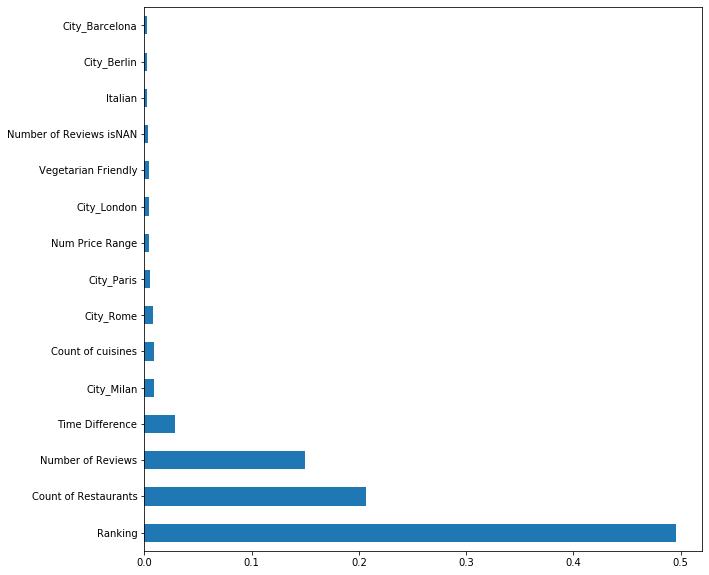

In [51]:
plt.rcParams['figure.figsize'] = (10,10)
feat_importances = pd.Series(regr.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')